# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** TEST_surrogate_model  
**Author:** Jasper Cluistra  
**Last Updated:** 2026-02-10  

### Goal script:
goal is to test some various scripts and librarys for using a surrogate model

## 1. Simple Surrogate Model with Scikit-learn (Kriging/Gaussian Process)
Gaussian Processes (GP) are widely used for surrogate modeling because they provide both predictions and uncertainty estimates.

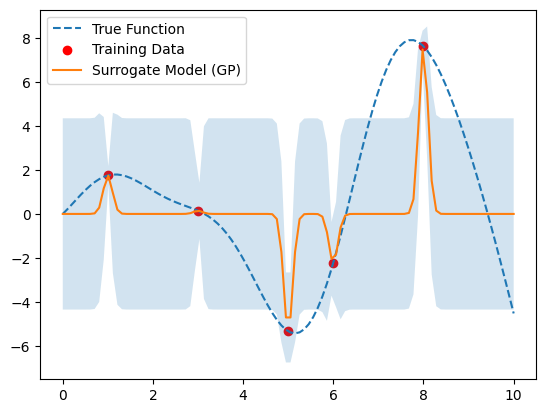

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import matplotlib.pyplot as plt

# 1. Define the "Expensive" Black-Box Function
def complex_simulation(x):
    return x * np.sin(x) + np.sin(2 * x)

# 2. Generate Training Data (Small set)
X_train = np.array([1, 3, 5, 6, 8]).reshape(-1, 1)
y_train = complex_simulation(X_train)

# 3. Define and Train the Surrogate Model (GP)
kernel = C(1.0) * RBF(1.0)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X_train, y_train)

# 4. Predict using the Surrogate Model
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred, sigma = gp.predict(X_plot, return_std=True)

# 5. Visualize
plt.plot(X_plot, complex_simulation(X_plot), label="True Function", linestyle='--')
plt.scatter(X_train, y_train, c='r', label="Training Data")
plt.plot(X_plot, y_pred, label="Surrogate Model (GP)")
plt.fill_between(X_plot.flatten(), y_pred - sigma, y_pred + sigma, alpha=0.2)
plt.legend()
plt.show()


## 2. Neural Network Surrogate (MLPRegressor)
For highly non-linear, high-dimensional data, a Multilayer Perceptron (MLP) can act as a robust surrogate.

In [6]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Assume X_train, y_train are pre-computed simulation data
# Use a pipeline to scale data for better NN performance
surrogate = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000))
])

surrogate.fit(X_train, y_train)
y_pred = surrogate.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


NameError: name 'X_test' is not defined